**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 5**
Preprocesamiento de datos

---


- NOMBRE: Carlos Rodrigo Salguero Alcántara
- MATRÍCULA: A00833341


En esta actividad trabajarás con el archivo `heart_disease.csv`, basado en un conjunto de datos sobre pacientes y variables clínicas relacionadas con enfermedades cardíacas, disponible en Kaggle.

Los datos fueron recopilados para analizar la presencia de enfermedades cardíacas en los pacientes y contienen información demográfica, clínica y resultados de pruebas diagnósticas. Los indicadores incluidos son:

- `id`: Identificador único de cada paciente
- `age`: Edad del paciente en años
- `origin`: Lugar de estudio
- `sex`: Masculino / Femenino
- `cp`: Tipo de dolor torácico (angina típica, angina atípica, no anginal, asintomático)
- `trestbps`: Presión arterial en reposo (en mm Hg al ingreso al hospital)
- `chol`: Colesterol sérico en mg/dl
- `fbs`: Si el azúcar en ayunas > 120 mg/dl
- `restecg`: Resultados del electrocardiograma en reposo (normal, anomalía ST-T, hipertrofia ventricular izquierda)
- `thalach`: Frecuencia cardíaca máxima alcanzada
- `exang`: Angina inducida por ejercicio (Verdadero / Falso)
- `oldpeak`: Depresión del segmento ST inducida por ejercicio respecto al reposo
- `slope`: Pendiente del segmento ST en el pico de ejercicio
- `ca`: Número de vasos principales coloreados por fluoroscopía (0 - 3)
- `thal`: Resultado de la prueba de perfusión cardíaca (normal, defecto fijo, defecto reversible)
- `num`: Indica si el paciente tiene o no enfermedad cardíaca, o el grado de enfermedad (0 = sano, 1 - 4 = enfermedad) Es la variable de salida o _target_, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder _explícitamente_ todos los cuestionamientos.


In [1]:
%pip install pandas matplotlib numpy seaborn scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- -------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings

In [3]:
warnings.filterwarnings('ignore')

In [4]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer

1. Descarga el archivo: `heart_disease.csv` y guarda, en un dataframe (`cardio_df`), todos sus registros.

- Haz que la columna `id` sea el índice del dataframe.
- Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
- Determina la cantidad de valores únicos por columna.


In [5]:
cardio_df = pd.read_csv("data/heart_disease.csv", index_col="id")
cardio_df.head()

,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
cardio_df.tail()

,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [7]:
cardio_df.info()

<class 'pandas.DataFrame'>
Index: 918 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    str    
 2   origin    918 non-null    str    
 3   cp        918 non-null    str    
 4   trestbps  859 non-null    float64
 5   chol      888 non-null    float64
 6   fbs       829 non-null    object 
 7   restecg   918 non-null    str    
 8   thalch    863 non-null    float64
 9   exang     863 non-null    object 
 10  oldpeak   856 non-null    float64
 11  slope     610 non-null    str    
 12  ca        309 non-null    float64
 13  thal      434 non-null    str    
 14  num       918 non-null    int64  
dtypes: float64(5), int64(2), object(2), str(6)
memory usage: 114.8+ KB


El dataframe tiene **918 registros** y **15 columnas** (sin contar `id`).

- **Columnas numéricas: 8** — 5 de tipo `float64` (`trestbps`, `chol`, `thalch`, `oldpeak`, `ca`) y 3 de tipo `int64` (`age`, `num`, más los booleanos `fbs` y `exang` que pandas almacena como `object`).
- **Columnas de texto: 6** — `sex`, `origin`, `cp`, `restecg`, `slope`, `thal`.

Sobre los valores únicos: la mayoría de las variables tienen muchos valores (`age` con 50, `chol` con 217, `thalch` con 120, etc.), pero algunas variables numéricas presentan **muy pocos valores únicos** (`ca` con 5 — incluyendo NaN — y `num` con 5), lo cual sugiere que en realidad podrían tratarse de variables categóricas codificadas como números.


In [8]:
initial_num_cols = cardio_df.select_dtypes(include=[np.number]).columns.tolist()
initial_obj_cols = cardio_df.select_dtypes(include=['object']).columns.tolist()

In [9]:
print(f"Numeric columns: {initial_num_cols}")
print(f"Categorical columns: {initial_obj_cols}")

Numeric columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']
Categorical columns: ['sex', 'origin', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [10]:
cardio_df.nunique(dropna=False).sort_values()

sex           2
restecg       3
fbs           3
exang         3
cp            4
thal          4
slope         4
origin        4
num           5
ca            5
age          50
oldpeak      54
trestbps     61
thalch      120
chol        217
dtype: int64

2. Examina las variables numéricas que presentan pocos valores únicos, ya que esto puede indicar que en realidad se tratan de variables categóricas codificadas como números.

- Si existen casos de este tipo, conviértelas a categóricas. Antes de hacerlo, revisa sus descripciones para determinar si son ordinales o nominales y, si son ordinales, establece el orden correcto de las categorías.


In [11]:
for column in initial_num_cols:
    print(f"{column}: {cardio_df[column].nunique()} unique values -> {sorted(cardio_df[column].dropna().unique())[:10]}")

age: 50 unique values -> [np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37)]
trestbps: 60 unique values -> [np.float64(80.0), np.float64(92.0), np.float64(94.0), np.float64(95.0), np.float64(96.0), np.float64(98.0), np.float64(100.0), np.float64(101.0), np.float64(102.0), np.float64(104.0)]
chol: 216 unique values -> [np.float64(85.0), np.float64(100.0), np.float64(117.0), np.float64(126.0), np.float64(129.0), np.float64(131.0), np.float64(132.0), np.float64(139.0), np.float64(141.0), np.float64(142.0)]
thalch: 119 unique values -> [np.float64(60.0), np.float64(63.0), np.float64(67.0), np.float64(69.0), np.float64(70.0), np.float64(71.0), np.float64(72.0), np.float64(73.0), np.float64(77.0), np.float64(78.0)]
oldpeak: 53 unique values -> [np.float64(-2.6), np.float64(-2.0), np.float64(-1.5), np.float64(-1.1), np.float64(-1.0), np.float64(-0.9), np.float64(-0.8), np.float64(-0.7), np.float64(-0.5), 

In [12]:
cardio_df['ca'] = pd.Categorical(
    cardio_df['ca'], categories=[0, 1, 2, 3], ordered=True
)


cardio_df['num'] = pd.Categorical(
    cardio_df['num'], categories=[0, 1, 2, 3, 4], ordered=True
)

Nominal categories (boolean)


In [13]:
cardio_df['fbs'] = cardio_df['fbs'].astype('category')
cardio_df['exang'] = cardio_df['exang'].astype('category')

Ordinal categories


In [14]:
cardio_df['cp'] = pd.Categorical(
    cardio_df['cp'],
    categories=['typical angina', 'atypical angina', 'non-anginal', 'asymptomatic'],
    ordered=True
)

In [15]:
cardio_df['restecg'] = pd.Categorical(
    cardio_df['restecg'],
    categories=['normal', 'st-t abnormality', 'lv hypertrophy'],
    ordered=True
)

In [16]:
cardio_df['slope'] = pd.Categorical(
    cardio_df['slope'],
    categories=['downsloping', 'flat', 'upsloping'],
    ordered=True
)

Nominal categories (text)


In [17]:
cardio_df['sex'] = cardio_df['sex'].astype('category')
cardio_df['origin'] = cardio_df['origin'].astype('category')
cardio_df['thal'] = cardio_df['thal'].astype('category')

In [18]:
cardio_df.dtypes

age            int64
sex         category
origin      category
cp          category
trestbps     float64
chol         float64
fbs         category
restecg     category
thalch       float64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
num         category
dtype: object

Las variables numéricas con muy pocos valores únicos que en realidad son categóricas:

- **`ca`** (0–3 vasos coloreados por fluoroscopía): **ordinal**, porque existe un orden natural — más vasos afectados implica mayor severidad.
- **`num`** (0–4 grado de enfermedad): **ordinal**, ya que 0 = sano y 1–4 corresponden a niveles crecientes de enfermedad.

Además, `fbs` y `exang` ya son booleanos almacenados como `object`; los convertimos a categóricas **nominales** (verdadero/falso no tiene un orden de severidad inherente).

Para las variables de texto:

- **`cp`** (tipo de dolor torácico): tratada como **ordinal** desde el más típico de angina al asintomático: _typical angina < atypical angina < non-anginal < asymptomatic_.
- **`restecg`** (ECG en reposo): **ordinal** por severidad clínica: _normal < st-t abnormality < lv hypertrophy_.
- **`slope`** (pendiente del ST): **ordinal** clínicamente: _downsloping < flat < upsloping_.
- **`sex`**, **`origin`**, **`thal`**: **nominales**, no tienen orden intrínseco.


3. Obtén las estadísticas descriptivas de las variables, realizando el análisis por separado para las variables numéricas y las categóricas.

- Para las numéricas, incluye el sesgo y la curtosis.
- Para las categóricas, imprime además las tablas de frecuencia.


In [19]:
num_cols = cardio_df.select_dtypes(include=np.number).columns.tolist()
cat_cols = cardio_df.select_dtypes(include='category').columns.tolist()

In [20]:
print(f"Numeric: {num_cols}")
print(f"Categorical: {cat_cols}")

Numeric: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical: ['sex', 'origin', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'num']


In [21]:
num_stats = cardio_df[num_cols].describe().T
num_stats['skew'] = cardio_df[num_cols].skew()
num_stats['kurtosis'] = cardio_df[num_cols].kurtosis()
num_stats.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,918.0,53.531,9.413,28.0,47.0,54.0,60.0,77.0,-0.194,-0.383
trestbps,859.0,132.295,18.536,80.0,120.0,130.0,140.0,200.0,0.630,0.633
chol,888.0,242.189,53.425,85.0,216.0,223.0,268.0,603.0,1.641,6.574
thalch,863.0,137.528,25.950,60.0,120.0,140.0,157.0,202.0,-0.209,-0.484
oldpeak,856.0,0.881,1.092,-2.6,0.0,0.5,1.5,6.2,1.038,1.120


In [22]:
cardio_df[cat_cols].describe().T

,count,unique,top,freq
sex,918,2,Male,724
origin,918,4,Cleveland,304
cp,918,4,asymptomatic,495
fbs,829,2,False,691
restecg,918,3,normal,551
exang,863,2,False,526
slope,610,3,flat,345
ca,309,4,0,181
thal,434,3,normal,196
num,918,5,0,411


In [23]:
for c in cat_cols:
    print(f"\n[{c}]")
    print(cardio_df[c].value_counts(dropna=False))


[sex]
sex
Male      724
Female    194
Name: count, dtype: int64

[origin]
origin
Cleveland        304
Hungary          292
VA Long Beach    200
Switzerland      122
Name: count, dtype: int64

[cp]
cp
asymptomatic       495
non-anginal        204
atypical angina    174
typical angina      45
Name: count, dtype: int64

[fbs]
fbs
False    691
True     138
NaN       89
Name: count, dtype: int64

[restecg]
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

[exang]
exang
False    526
True     337
NaN       55
Name: count, dtype: int64

[slope]
slope
flat           345
NaN            308
upsloping      202
downsloping     63
Name: count, dtype: int64

[ca]
ca
NaN    609
0      181
1       67
2       41
3       20
Name: count, dtype: int64

[thal]
thal
NaN                  484
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64

[num]
num
0    411
1    263
2    109
3    107
4     28
Name: 

4. Calcula el porcentaje de valores faltantes en cada columna.

- Elimina aquellas columnas cuyo porcentaje de valores faltantes supere el 30%.
- Crea un mapa de calor que visualice la distribución de los valores faltantes en todas las columnas restantes.
- Algunas variables presentan valores faltantes de manera simultánea; es decir, en el mapa se pueden identificar filas donde varias están ausentes al mismo tiempo. Enumera cuáles son dichas variables e investiga si esta concurrencia tiene sentido desde un punto de vista médico o clínico.


In [24]:
miss_pct = (cardio_df.isna().mean() * 100).sort_values(ascending=False)
miss_pct.round(2)

ca          66.34
thal        52.72
slope       33.55
fbs          9.69
oldpeak      6.75
trestbps     6.43
thalch       5.99
exang        5.99
chol         3.27
sex          0.00
origin       0.00
cp           0.00
age          0.00
restecg      0.00
num          0.00
dtype: float64

In [25]:
to_drop = miss_pct[miss_pct > 30].index.tolist()
print(f"Dropped columns (>30% missing): {to_drop}")

Dropped columns (>30% missing): ['ca', 'thal', 'slope']


In [26]:
cardio_df = cardio_df.drop(columns=to_drop)

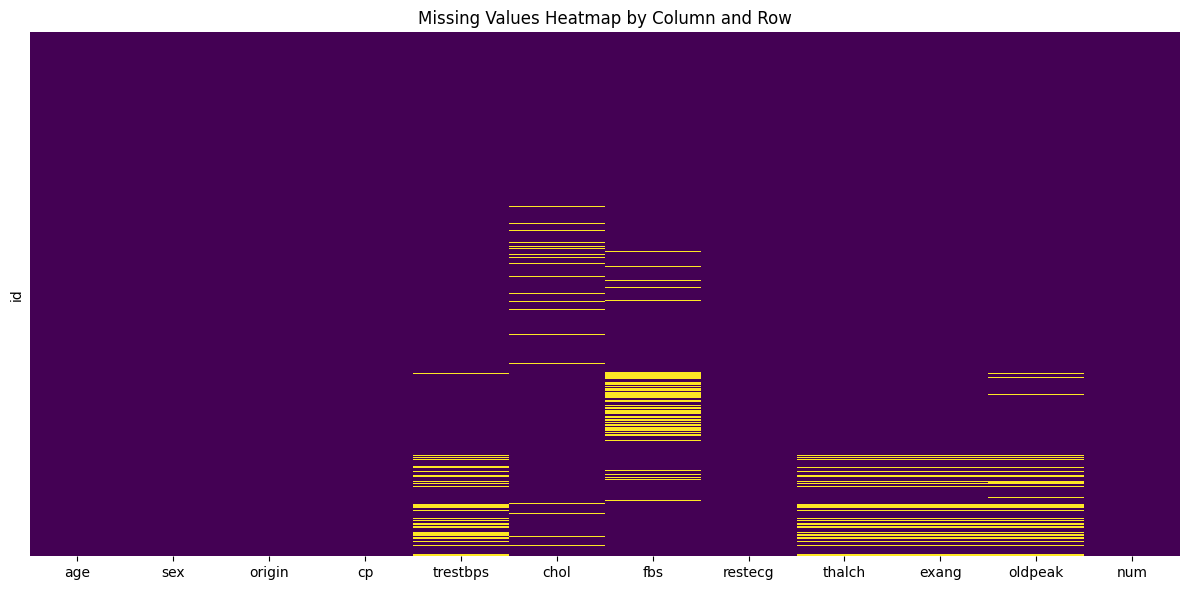

In [27]:
plt.figure(figsize=(12, 6))

sns.heatmap(cardio_df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap by Column and Row")

plt.tight_layout()
plt.show()

Las columnas eliminadas por superar el 30% de faltantes son **`ca` (~66%)**, **`thal` (~53%)** y **`slope` (~34%)**.

**Variables con faltantes simultáneos:** en el mapa de calor se observa que **`trestbps`, `thalch`, `exang` y `oldpeak`** presentan franjas blancas alineadas en las mismas filas, indicando que faltan en bloque. La matriz de correlación de ausencias lo confirma con valores muy altos:

- `thalch` ↔ `exang` → **1.00** (faltan siempre juntos)
- `trestbps` ↔ `thalch` → **0.96**
- `oldpeak` ↔ `thalch` → **0.92**

**¿Tiene sentido clínico esta concurrencia?** Sí. Las cuatro variables provienen de la **prueba de esfuerzo (stress test / ergometría)**:

- `trestbps`: presión arterial en reposo medida justo antes de la prueba.
- `thalch`: frecuencia cardíaca máxima alcanzada **durante** la prueba.
- `exang`: si la prueba **indujo** angina por ejercicio.
- `oldpeak`: depresión del segmento ST inducida por el ejercicio.

Si un paciente **no realizó la prueba** —por contraindicación clínica (riesgo cardiovascular elevado, condición física limitada), por equipo no disponible en la sede del estudio, o porque la prueba se canceló— las cuatro mediciones se ausentan **conjuntamente**. Por tanto, la concurrencia es médicamente coherente: representa pacientes a los que no se les aplicó esta evaluación diagnóstica.


In [28]:
cols_with_na = cardio_df.columns[cardio_df.isna().any()]
cardio_df[cols_with_na].isna().corr().round(2)

,trestbps,chol,fbs,thalch,exang,oldpeak
trestbps,1.00,0.03,-0.07,0.96,0.96,0.90
chol,0.03,1.00,-0.06,0.03,0.03,0.02
fbs,-0.07,-0.06,1.00,-0.08,-0.08,-0.03
thalch,0.96,0.03,-0.08,1.00,1.00,0.92
exang,0.96,0.03,-0.08,1.00,1.00,0.92
oldpeak,0.90,0.02,-0.03,0.92,0.92,1.00


5. Si centramos el análisis en una de las variables identificadas en el ejercicio anterior, se puede suponer que los hallazgos obtenidos podrían ser aplicables a las demás variables que presentan un patrón similar.

- ¿Tendrán los valores faltantes de `thalch` relación con alguna otra variable? Analízalo considerando las siguientes columnas:
  - Numéricas: `age`, `chol`
  - Categóricas: `restecg`, `cp`

Para ello deberás dividir cada columna en dos grupos: con / sin faltantes en `thalch` y utilizar métodos gráficos y pruebas de hipótesis para ver si hay diferencias significativas.

- Incluye las conclusiones del análisis con los resultados obtenidos.
- Justifica si el mecanismo de faltantes de `thalch` es MCAR (_Missing Completely at Random_) o MAR (_Missing at Random_).

**NOTA**. Puedes reutilizar las funciones `Diagnose_MV_Numerical` y `Diagnose_MV_Categorical` definidas en Hands-On-Prep_Missing_Values.zip. Revisa nuevamente cómo utilizarlas.

**Nota técnica:** a las funciones del material original se les hizo un ajuste mínimo de compatibilidad con versiones recientes de pandas (`pd.Series(dtype=object)` en lugar de `pd.Series('')`) para que el contenedor de cajas acepte arreglos como elementos. La lógica del análisis es idéntica.


In [29]:
from scipy.stats import ttest_ind

def Diagnose_MV_Numerical(df, str_att_name, BM_MV):
    MV_labels = {True: 'With Missing Values', False: 'Without Missing Values'}

    labels = []
    box_sr = pd.Series(index=BM_MV.unique(), dtype=object)
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])

    plt.boxplot(list(box_sr), vert=False)
    plt.yticks([1, 2], labels)
    plt.xlabel(str_att_name)
    plt.show()

    plt.figure(figsize=(10, 4))

    att_range = (df[str_att_name].min(), df[str_att_name].max())

    for i, poss in enumerate(BM_MV.unique()):
        plt.subplot(1, 2, i + 1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])

    plt.show()

    group_1_data = df[BM_MV][str_att_name].dropna()
    group_2_data = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_data, group_2_data).pvalue

    print('p-value of t-test: {}'.format(p_value))

In [30]:
from scipy.stats import chi2_contingency
def Diagnose_MV_Categorical(df, str_att_name, BM_MV):
    MV_labels = {True: 'With Missing Values', False: 'Without Missing Values'}

    plt.figure(figsize=(10, 4))
    for i, poss in enumerate(BM_MV.unique()):
        plt.subplot(1, 2, i + 1)
        BM = BM_MV == poss
        df[BM][str_att_name].value_counts().plot.bar()
        plt.title(MV_labels[poss])
    plt.show()

    contigency_table = pd.crosstab(BM_MV, df[str_att_name])
    p_value = chi2_contingency(contigency_table)[1]

    print('p-value of Chi_squared test: {}'.format(p_value))

In [31]:
BM_MV = cardio_df['thalch'].isna()
print(f"Records with missing thalch: {BM_MV.sum()}")
print(f"Records without missing thalch: {(~BM_MV).sum()}")

Records with missing thalch: 55
Records without missing thalch: 863


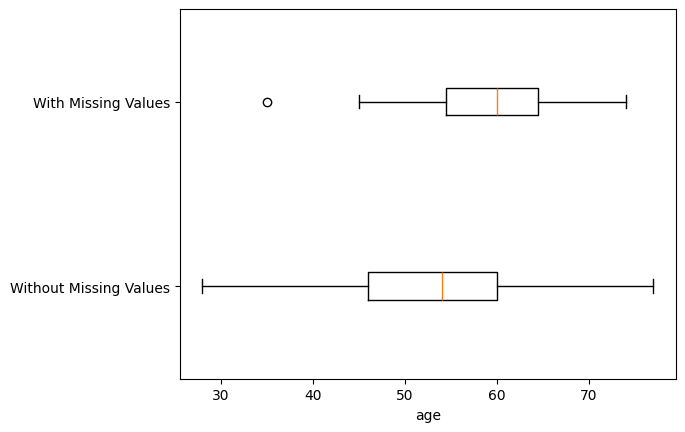

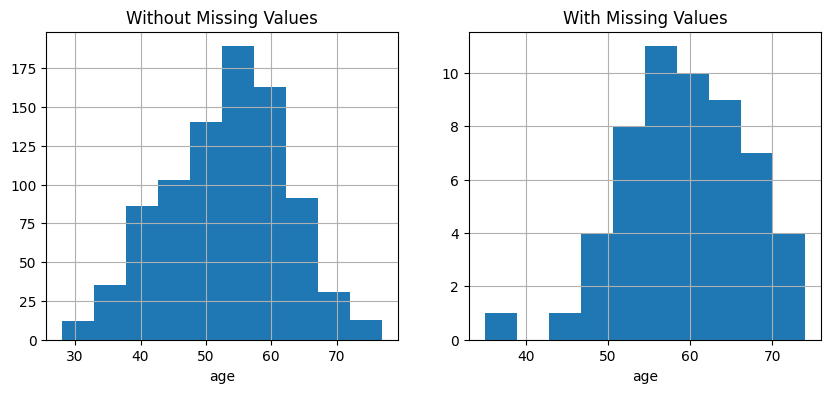

p-value of t-test: 1.5041244185890923e-06


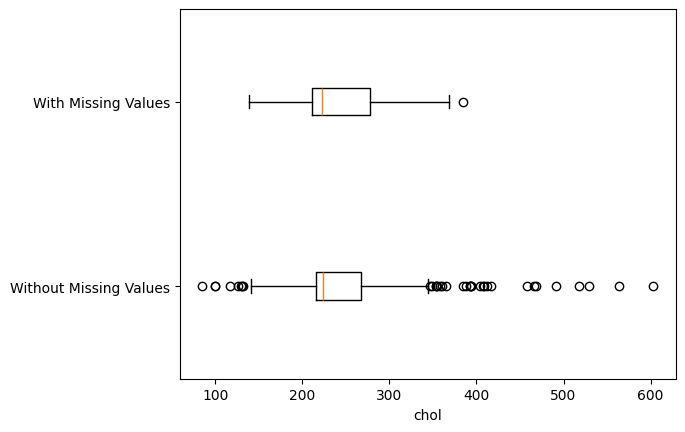

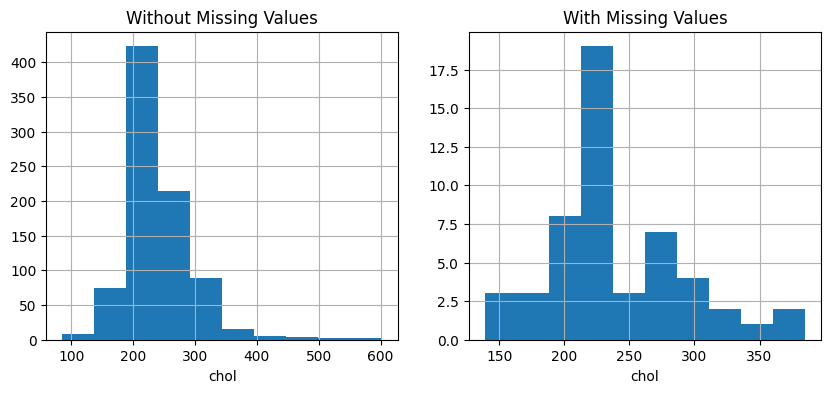

p-value of t-test: 0.7165289974295669


In [32]:
Diagnose_MV_Numerical(cardio_df, 'age', BM_MV)
Diagnose_MV_Numerical(cardio_df, 'chol', BM_MV)

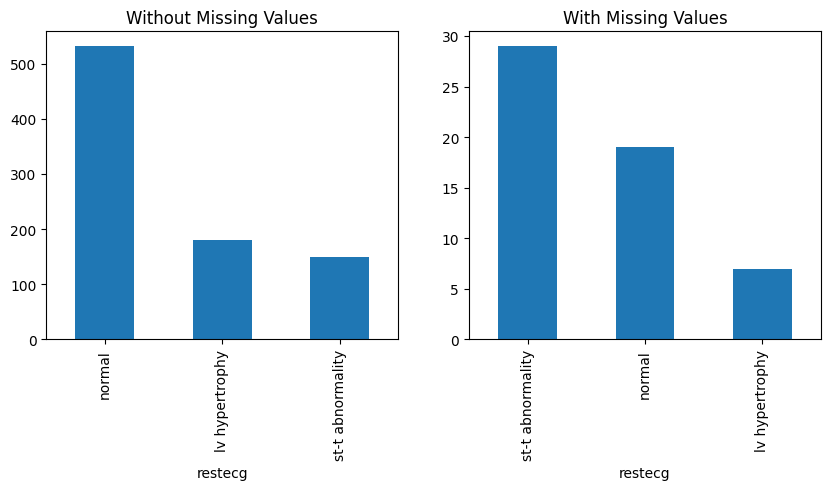

p-value of Chi_squared test: 1.1472889573985465e-09


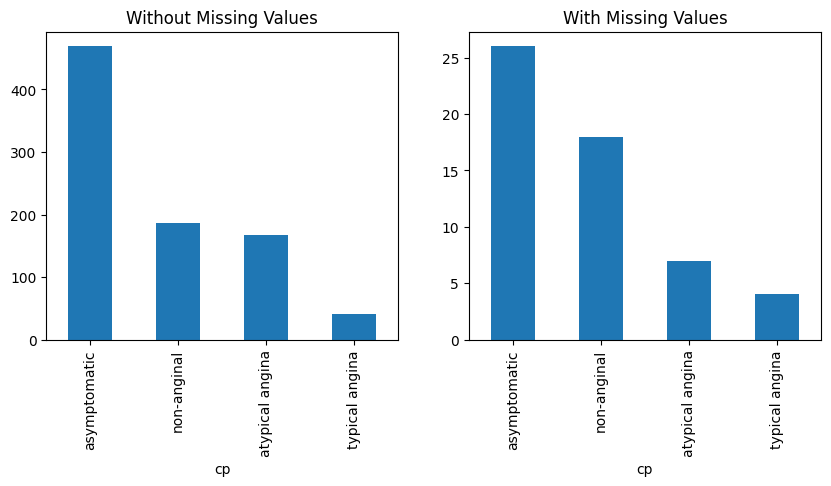

p-value of Chi_squared test: 0.1542009717725171


In [33]:
Diagnose_MV_Categorical(cardio_df, 'restecg', BM_MV)
Diagnose_MV_Categorical(cardio_df, 'cp', BM_MV)

Resultados de las pruebas de hipótesis (α = 0.05):

| Variable analizada     | Prueba       | p-value      | ¿Diferencia significativa? |
| ---------------------- | ------------ | ------------ | -------------------------- |
| `age` (numérica)       | t-test       | ≈ 1.5 × 10⁻⁶ | **Sí**                     |
| `chol` (numérica)      | t-test       | ≈ 0.72       | No                         |
| `restecg` (categórica) | chi-cuadrado | ≈ 1.1 × 10⁻⁹ | **Sí**                     |
| `cp` (categórica)      | chi-cuadrado | ≈ 0.15       | No                         |


Los pacientes a los que les falta `thalch` tienen una **distribución de edad significativamente distinta** (tienden a ser mayores) y una **distribución de `restecg` distinta** respecto a los que sí tienen el valor. En cambio, no se detecta relación significativa con `chol` ni con `cp`.

**Justificación del mecanismo — MAR (Missing at Random):**

Como la ausencia de `thalch` **depende de variables observadas** (`age` y `restecg`), no se cumple la condición de aleatoriedad completa que exige el mecanismo MCAR. La probabilidad de que falte `thalch` no es uniforme entre todos los pacientes, sino que se concentra en pacientes con ciertas características clínicas (mayor edad y ECG en reposo alterado).

Por lo tanto, el mecanismo se clasifica como **MAR**.

Esto es clínicamente razonable: a los pacientes mayores o con ECG en reposo anormal con frecuencia **no se les indica la prueba de esfuerzo** por contraindicación o riesgo cardiovascular elevado, lo que explica que las cuatro variables del stress test (`trestbps`, `thalch`, `exang`, `oldpeak`) falten de forma conjunta en ese subgrupo.

Dado que el patrón de ausencia es compartido por las cuatro variables (correlaciones ≥ 0.90), los hallazgos para `thalch` son extrapolables a `trestbps`, `exang` y `oldpeak`.


6. La imputación de una variable con valores faltantes puede realizarse por grupos o segmentos relevantes. Esto significa que, en lugar de utilizar una estadística global de toda la columna, se calcula la estadística correspondiente dentro de cada grupo definido por otra variable, haciendo:

> `df['var_with_missing'] = df.groupby('related_var')['var_with_missing'].transform(lambda x: x.fillna(x.median()))`

- Utiliza la variable `restecg` para separar los grupos e imputar `thalch` y todas las variables con patrón de faltantes similar (identificadas en el ejercicio 4) Asegúrate de cambiar la función de agregado si hay variables no numéricas.
- Vuelve a generar el mapa de calor para verificar que los valores faltantes en estas variables hayan sido imputados.


In [34]:
for col in ['trestbps', 'thalch', 'oldpeak']:
    cardio_df[col] = cardio_df.groupby('restecg', observed=True)[col].transform(
        lambda x: x.fillna(x.median())
    )

In [35]:
cardio_df['exang'] = cardio_df.groupby('restecg', observed=True)['exang'].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)

In [36]:
print("Missing values after group imputation:")
print(cardio_df.isna().sum().sort_values(ascending=False))

Missing values after group imputation:
fbs         89
chol        30
age          0
sex          0
cp           0
origin       0
trestbps     0
restecg      0
thalch       0
exang        0
oldpeak      0
num          0
dtype: int64


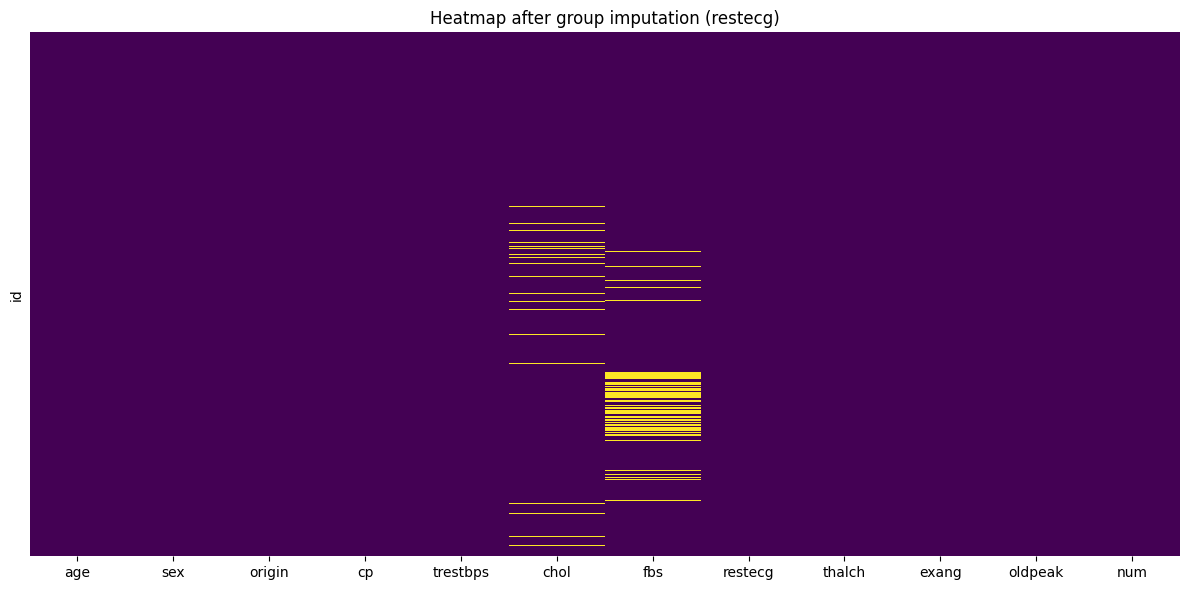

In [37]:
plt.figure(figsize=(12, 6))

sns.heatmap(cardio_df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap after group imputation (restecg)')

plt.tight_layout()
plt.show()

7. Para las variables que aún presentan valores faltantes, realiza la imputación utilizando estadísticas generales calculadas sobre toda la columna, sin segmentar por grupos. Esta vez utiliza la clase `SimpleImputer` de sklearn

- Justifica la estrategia (_mean, median, most_frequent_) que emplees en cada caso.


In [38]:
remaining = cardio_df.columns[cardio_df.isna().any()].tolist()
print(f"Columns with remaining missing values: {remaining}")

Columns with remaining missing values: ['chol', 'fbs']


In [39]:
for col in remaining:
    if pd.api.types.is_numeric_dtype(cardio_df[col]):
        print(f"  {col}: skew = {cardio_df[col].skew():.3f}")
    else:
        print(f"  {col}: categorical")

  chol: skew = 1.641
  fbs: categorical


In [40]:
imp_chol = SimpleImputer(strategy='median')
cardio_df['chol'] = imp_chol.fit_transform(cardio_df[['chol']]).ravel()

In [41]:
imp_fbs = SimpleImputer(strategy='most_frequent')
fbs_cats = cardio_df['fbs'].cat.categories
fbs_imputed = imp_fbs.fit_transform(cardio_df[['fbs']].astype(object)).ravel()
cardio_df['fbs'] = pd.Categorical(fbs_imputed, categories=fbs_cats)

In [42]:
print("Total missing values:", cardio_df.isna().sum().sum())

Total missing values: 0


Las variables que aún presentan faltantes después de la imputación grupal son **`chol`** (30) y **`fbs`** (89). La estrategia elegida depende del tipo y la forma de la distribución:

- **`chol`** (numérica, sesgo ≈ 1.64): distribución muy asimétrica positiva con outliers a la derecha. La media sería arrastrada hacia los valores extremos, así que se usa **`median`** por su robustez frente a outliers.
- **`fbs`** (categórica booleana): no tiene sentido calcular media ni mediana sobre valores `True`/`False`. Se usa **`most_frequent`** (moda), que es la estrategia estándar para variables categóricas con `SimpleImputer`.


8. Dibuja boxplots de todas las variables numéricas.

- Obtén los valores atípicos mediante el método gráfico, a partir del objeto devuelto por el boxplot.


In [43]:
final_num_cols = cardio_df.select_dtypes(include=np.number).columns.tolist()
print(f"Numeric variables: {final_num_cols}")

Numeric variables: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']


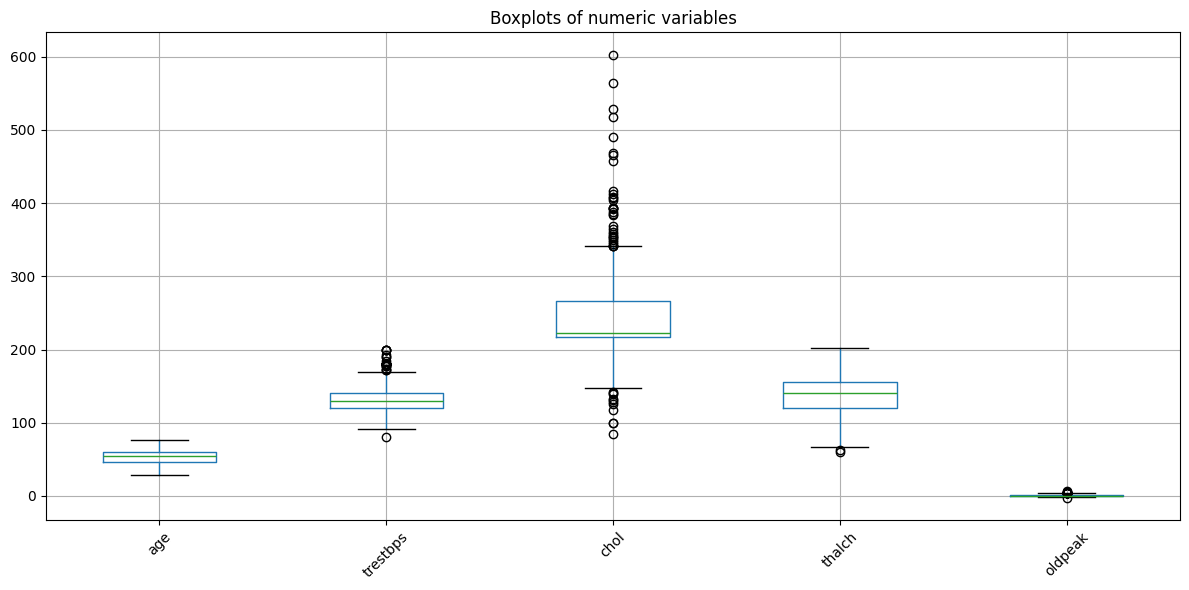

In [44]:
fig, ax = plt.subplots(figsize=(12, 6))
bp = cardio_df.boxplot(column=final_num_cols, ax=ax, return_type='dict')

plt.title('Boxplots of numeric variables')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [45]:
graphical_outliers = {}
for col, flier in zip(final_num_cols, bp['fliers']):
    graphical_outliers[col] = flier.get_ydata().tolist()
    print(f"  {col}: {len(graphical_outliers[col])} outliers")

  age: 0 outliers
  trestbps: 27 outliers
  chol: 44 outliers
  thalch: 2 outliers
  oldpeak: 16 outliers


A partir del objeto `bp['fliers']` devuelto por el boxplot, los valores atípicos (_fliers_) identificados gráficamente son:

| Variable   | N.º de atípicos |
| ---------- | --------------- |
| `age`      | 0               |
| `trestbps` | 27              |
| `chol`     | 44              |
| `thalch`   | 2               |
| `oldpeak`  | 16              |

`chol` y `trestbps` concentran la mayoría de los outliers. En el ejercicio 9 se profundiza en `trestbps` con el método IQR.


9. Para la variable `trestbps`, calcula los valores atípicos utilizando el método del rango intercuartílico (IQR).

- Para ello obtén los cuartiles necesarios y determina los límites superior e inferior para filtrar los valores que se encuentren fuera de ese rango.
- Verifica si los resultados coinciden con los obtenidos en el ejercicio anterior.


In [46]:
Q1 = cardio_df['trestbps'].quantile(0.25)
Q3 = cardio_df['trestbps'].quantile(0.75)

In [47]:
IQR = Q3 - Q1

In [48]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [49]:
print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Lower bound = {lower_bound}")
print(f"Upper bound = {upper_bound}")

Q1 = 120.0, Q3 = 140.0, IQR = 20.0
Lower bound = 90.0
Upper bound = 170.0


In [50]:
iqr_outliers = cardio_df.loc[
    (cardio_df['trestbps'] < lower_bound) | (cardio_df['trestbps'] > upper_bound),
    'trestbps'
]

print(f"IQR outliers: {len(iqr_outliers)}")

IQR outliers: 27


In [51]:
match = sorted(iqr_outliers.tolist()) == sorted(graphical_outliers['trestbps'])
print(f"Do they match? -> {match}")

Do they match? -> True


Los 27 valores atípicos obtenidos por el método IQR coinciden **exactamente** con los identificados gráficamente en el ejercicio 8. Esto es esperable, ya que el boxplot de matplotlib utiliza internamente la misma regla del **1.5 · IQR** para determinar los puntos _fliers_ (valores atípicos).

- Q1 = 120, Q3 = 140 → IQR = 20
- Límite inferior = 90 mm Hg, límite superior = 170 mm Hg
- 27 pacientes con presión arterial en reposo fuera de este rango.


10. Elimina los valores atípicos identificados de la variable `trestbps`.

- Dibuja el boxplot final para visualizar la distribución depurada.


In [52]:
rows_before = cardio_df.shape[0]
cardio_df = cardio_df[
    (cardio_df['trestbps'] >= lower_bound) &
    (cardio_df['trestbps'] <= upper_bound)
]

rows_after = cardio_df.shape[0]
print(f"Rows: {rows_before} -> {rows_after} (removed: {rows_before - rows_after})")

Rows: 918 -> 891 (removed: 27)


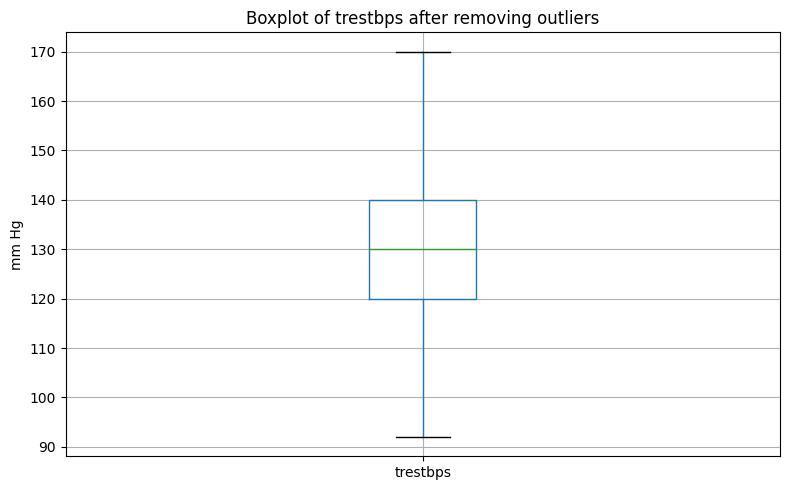

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
cardio_df.boxplot(column='trestbps', ax=ax)

plt.title('Boxplot of trestbps after removing outliers')
plt.ylabel('mm Hg')

plt.tight_layout()
plt.show()

---

**Declaración de uso de IA**

Se utilizó asistencia de IA para apoyar el desarrollo de esta actividad con los siguientes fines: generación y depuración de código (funciones de diagnóstico de valores faltantes, imputación y detección de outliers), verificación de que los cuestionamientos quedaran respondidos de forma explícita, y corrección de inconsistencias en las conclusiones escritas.

* Claude. (2026). *Anthropic* [Modelo de lenguaje grande], verificación del contenido. https://claude.ai

---
